In [78]:
import pandas as pd
from sklearn import datasets
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

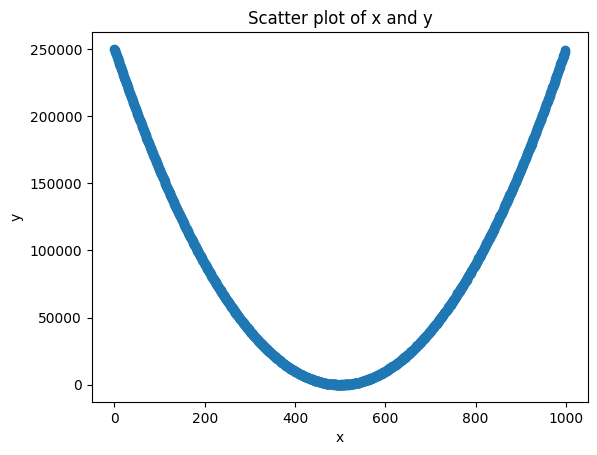

In [79]:
x = list(range(1000))
y = [(i-500)**2 + np.random.normal(0, i/4) for i in x]
df = pd.DataFrame({'x': x, 'y': y})
plt.scatter(df['x'], df['y'])
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter plot of x and y')
plt.show()

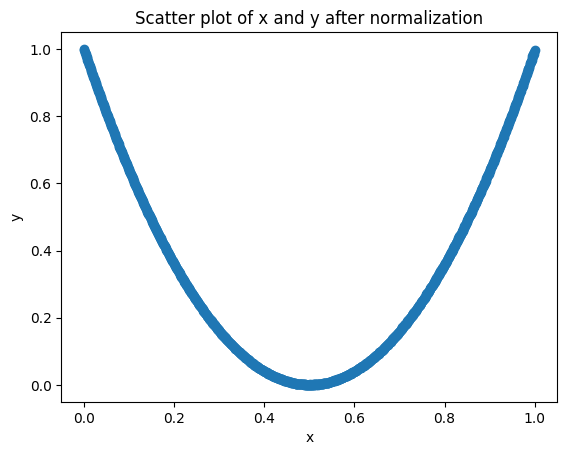

In [80]:
# normalize the data min max scaler
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df[['x', 'y']] = scaler.fit_transform(df[['x', 'y']])
plt.scatter(df['x'], df['y'])
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter plot of x and y after normalization')
plt.show()

In [81]:
x_train = df[['x', 'y']].values
x_train.shape

(1000, 2)

In [82]:
import keras

In [83]:
input_shape = (2,)
#encoder = keras.models.Sequential([keras.layers.Dense(2)])
#decoder = keras.models.Sequential([keras.layers.Dense(input_shape[0])])

stacked_encoder = keras.models.Sequential([
        keras.layers.Dense(50, activation="relu"),
        keras.layers.Dense(50, activation="relu"),
        keras.layers.Dense(1, activation="relu"),
        ])

stacked_decoder = keras.models.Sequential([
        keras.layers.Dense(50, activation="relu", input_shape=[1]),
        keras.layers.Dense(50, activation="relu"),
        keras.layers.Dense(input_shape[0], activation="sigmoid"),
        ])



autoencoder = keras.Sequential([
        keras.layers.Input(shape=input_shape),
        stacked_encoder, 
        stacked_decoder
])
autoencoder.summary()


c:\Users\marco\Dropbox\Documenti\DIDATTICA\ai-academy-kohler\venv\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_24 (Sequential)      │ (None, 1)              │         2,751 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_25 (Sequential)      │ (None, 2)              │         2,752 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,503 (21.50 KB)

 Trainable params: 5,503 (21.50 KB)

 Non-trainable params: 0 (0.00 B)

In [84]:
autoencoder.compile(loss="mse", optimizer=keras.optimizers.SGD(learning_rate=0.1))
history = autoencoder.fit(x_train, x_train, epochs=50)
codings = stacked_encoder.predict(x_train)

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0966 
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0914
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0864
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0873
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0808 
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0838 
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0841 
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0812
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0804 
Epoch 10/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0760 
Epoch 11/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0726 
Epoch 12/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0688
Epoch 13/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0618 
Epoch 14/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0592 
Epoch 15/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0502 
Epoch 16/

In [85]:
T = codings
T.shape

(1000, 1)

In [86]:
newdf = stacked_decoder.predict(T)
newdf

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


array([[0.01181076, 0.75584793],
       [0.01196105, 0.75473195],
       [0.01211407, 0.7536062 ],
       ...,
       [0.71138287, 0.20976989],
       [0.71138287, 0.20976989],
       [0.71138287, 0.20976989]], dtype=float32)

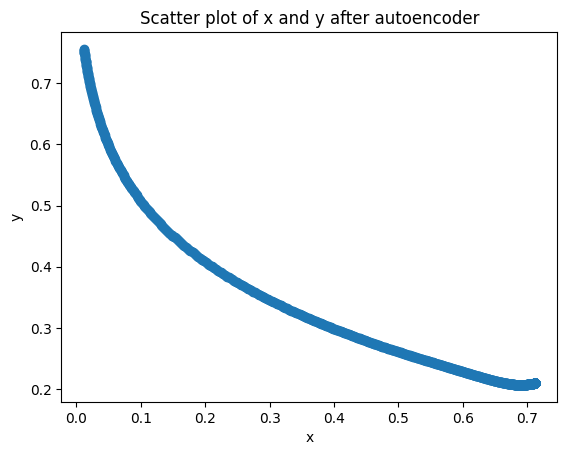

In [87]:
plt.scatter(newdf[:, 0], newdf[:, 1])
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter plot of x and y after autoencoder')
plt.show()